In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score,silhouette_samples
from collections import Counter
import matplotlib.cm as cm

In [9]:
# Chargement des données
df = pd.read_csv("../donnees/tmdb_5000_movies_nettoyer.csv")
donnees_fusionnees_chargees = np.load("../donnees/donnees_fusionnees.npy", allow_pickle=True)
embeddings = np.load("../donnees/embeddings_films.npy", allow_pickle=True)

### Déterminer le nombre optimal de clusters (méthode du coude & Score Silhouette)

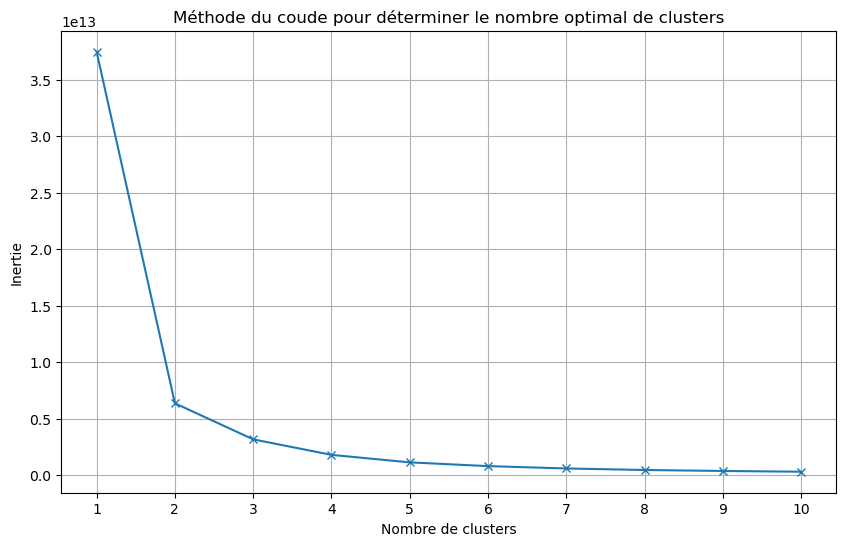

In [11]:
# Méthode du coude (Elbow Method)
inerties = []
for n_clusters in range(1, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(donnees_fusionnees_chargees)
    inerties.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inerties, marker='x')
plt.title("Méthode du coude pour déterminer le nombre optimal de clusters")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [ ]:
# Score Silhouette
silhouette_scores = []
for n_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(donnees_fusionnees_chargees)
    score = silhouette_score(donnees_fusionnees_chargees, labels)
    silhouette_scores.append(score)
    print(f"Clusters: {n_clusters}, Score Silhouette: {score:.3f}")

Clusters: 2, Score Silhouette: 0.833
Clusters: 3, Score Silhouette: 0.744
Clusters: 4, Score Silhouette: 0.702
Clusters: 5, Score Silhouette: 0.699
Clusters: 6, Score Silhouette: 0.673
Clusters: 7, Score Silhouette: 0.664
Clusters: 8, Score Silhouette: 0.665
Clusters: 9, Score Silhouette: 0.555
Clusters: 10, Score Silhouette: 0.553


### Appliquer le k-means avec le nombre optimal de clusters

In [ ]:

nombre_clusters=4    # À déterminer visuellement depuis le graphique du coude

kmeans_model = KMeans(n_clusters=nombre_clusters, random_state=42, n_init=10)
# Entrainement du model
kmeans_model.fit(donnees_fusionnees_chargees)

if len(kmeans_model.labels_) == len(df):
    df['cluster_label'] = kmeans_model.labels_
else:
    print(f"Attention : Le nombre d'étiquettes ({len(kmeans_model.labels_)}) ne correspond pas au nombre de lignes du DataFrame ({len(df)}). Impossible d'assigner les étiquettes de cluster.")

if 'cluster_label' in df.columns:
    print("Distribution des films par cluster :")
    print(df['cluster_label'].value_counts())
else:
    print("Les étiquettes de cluster n'ont pas été assignées au DataFrame.")

Distribution des films par cluster :
cluster_label
2    3270
0     821
1     367
3     342
Name: count, dtype: int64


### Évaluer les performances du clustering

Pour n_clusters = 4, le score de silhouette moyen est : 0.70


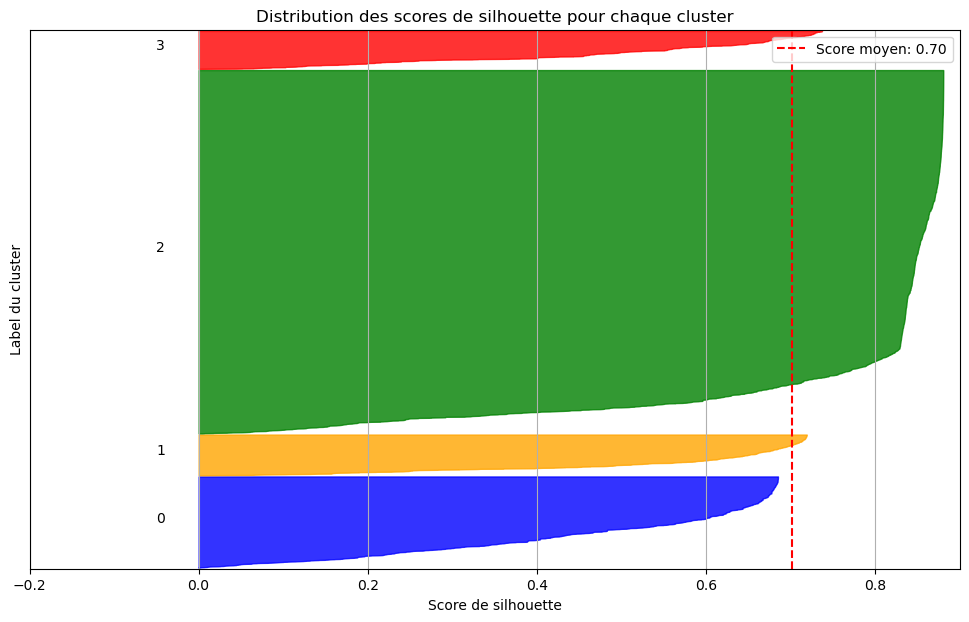

In [27]:
# distribution et affichage du score de silhouette par cluster
fig, ax1 = plt.subplots(1, 1)
fig.set_size_inches(12, 7)

ax1.set_xlim([-0.2, 0.9])
ax1.set_ylim([0, len(donnees_fusionnees_chargees) + (nombre_clusters + 1) * 10])

cluster_labels = kmeans_model.fit_predict(donnees_fusionnees_chargees)

# Calcul du score de silhouette moyen.
silhouette_avg = silhouette_score(donnees_fusionnees_chargees, cluster_labels)
print(
    f"Pour n_clusters = {nombre_clusters}, "
    f"le score de silhouette moyen est : {silhouette_avg:.2f}"
)

sample_silhouette_values = silhouette_samples(donnees_fusionnees_chargees, cluster_labels)

y_lower = 10

cluster_colors = {0: 'blue', 1: 'orange', 2: 'green', 3: 'red' }
for i in range(nombre_clusters):
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cluster_colors[i]

    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, 
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.8,
    )
    # l' id du cluster
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10  

# Titre et labels des axes
ax1.set_title("Distribution des scores de silhouette pour chaque cluster")
ax1.set_xlabel("Score de silhouette")
ax1.set_ylabel("Label du cluster")

ax1.axvline(x=silhouette_avg, color="red", linestyle="--", label=f'Score moyen: {silhouette_avg:.2f}')

# légende
ax1.legend(loc='upper right')

ax1.set_yticks([])
ax1.grid(True)

# Affichage 
plt.show()

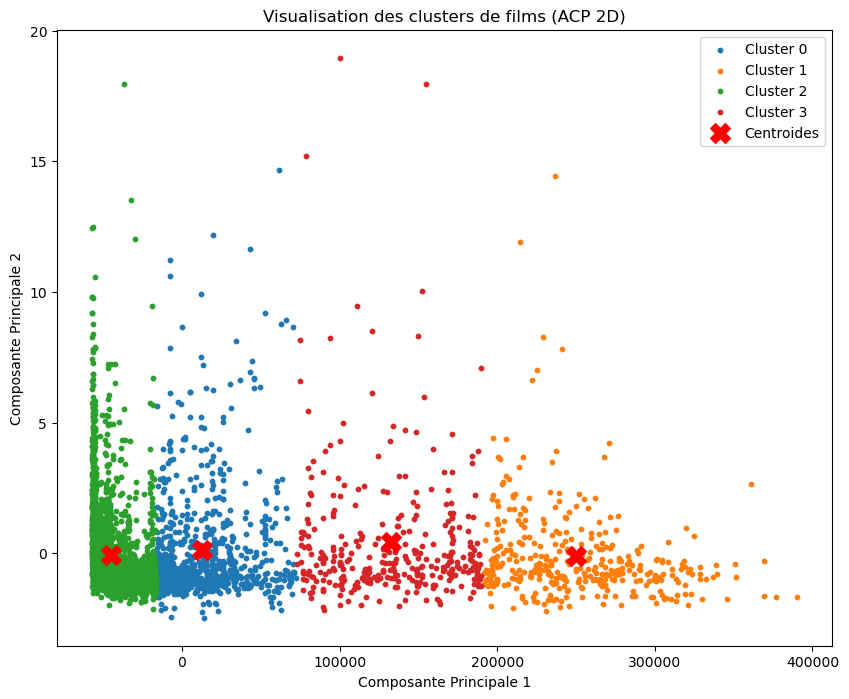

In [14]:
# Visualisation par ACP
pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(donnees_fusionnees_chargees)

if 'cluster_label' in df.columns:
    valid_indices = df.index[df['cluster_label'].notna()].tolist()

    if len(valid_indices) != embeddings_pca.shape[0]:
        print("Attention : décalage dans le nombre d'échantillons entre les étiquettes de cluster et les incorporations ACP.")
        min_len = min(len(valid_indices), embeddings_pca.shape[0])
        embeddings_pca = embeddings_pca[:min_len]
        cluster_labels_to_plot = df['cluster_label'].iloc[:min_len]
    else:
        cluster_labels_to_plot = df['cluster_label']
        
    plt.figure(figsize=(10, 8))
    # Representation des clusters avec differentes couleurs 
    for cluster_id in sorted(cluster_labels_to_plot.unique()):
        plt.scatter(embeddings_pca[cluster_labels_to_plot == cluster_id, 0],
                    embeddings_pca[cluster_labels_to_plot == cluster_id, 1],
                    s=10, label=f'Cluster {cluster_id}')

    plt.title("Visualisation des clusters de films (ACP 2D)")
    plt.xlabel("Composante Principale 1")
    plt.ylabel("Composante Principale 2")

    # Calculer et montrer les centroïdes
    cluster_centers_pca = []
    for cluster_id in range(nombre_clusters):
        cluster_points = embeddings_pca[cluster_labels_to_plot == cluster_id]
        if cluster_points.shape[0] > 0:
            cluster_centers_pca.append(cluster_points.mean(axis=0))
        else:
            cluster_centers_pca.append([np.nan, np.nan]) 

    cluster_centers_pca = np.array(cluster_centers_pca)

    # Filtrer les centroïdes NAN avant de comploter
    valid_centroids_pca = cluster_centers_pca[~np.isnan(cluster_centers_pca).any(axis=1)]

    plt.scatter(valid_centroids_pca[:, 0], valid_centroids_pca[:, 1], marker='X', s=200, color='red', label='Centroides') 
    plt.legend() 
    plt.show()
else:
    print("Erreur: la colonne 'Cluster_Label' est manquante dans le dataframe. Veuillez vérifier les étapes du regroupement et de l'étiquette.")


Réduction de dimensionnalité avec t-SNE pour une meilleure vue...


/home/mg4/miniconda3/envs/Mg4_IA/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/home/mg4/miniconda3/envs/Mg4_IA/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/home/mg4/miniconda3/envs/Mg4_IA/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/home/mg4/miniconda3/envs/Mg4_IA/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


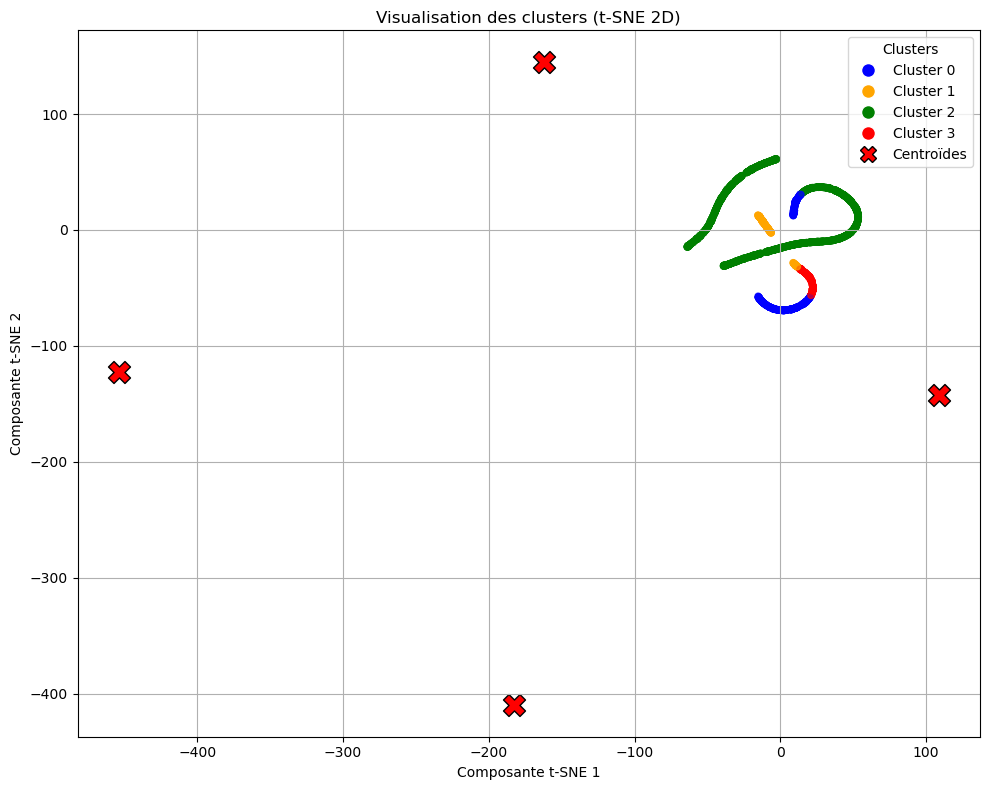

In [19]:

# visualistion par t-SNE 

print("\nRéduction de dimensionnalité avec t-SNE pour une meilleure vue...")

# Création d'un sous-échantillon pour accélérer le calcul, car t-SNE est coûteux en calcul
sample_size = min(2500, len(donnees_fusionnees_chargees))
indices = np.random.choice(donnees_fusionnees_chargees.shape[0], sample_size, replace=False)
donnees_sample = donnees_fusionnees_chargees[indices]
labels_sample = df['cluster_label'].iloc[indices]

# Initialisation et application de l'algorithme t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=40, n_iter=2000) # Augmentation de n_iter pour une meilleure convergence
donnees_tsne = tsne.fit_transform(donnees_sample)

# Création du graphique
plt.figure(figsize=(10, 8)) 

# mm coloration que dans ACP 
cluster_colors = {0: 'blue', 1: 'orange', 2: 'green', 3: 'red' }
colors = [cluster_colors[label] for label in labels_sample]

# Affichage des points de données projetés par t-SNE
scatter_tsne = plt.scatter(donnees_tsne[:, 0], donnees_tsne[:, 1], c=colors, s=20, alpha=0.7)
plt.title("Visualisation des clusters (t-SNE 2D)")
plt.xlabel("Composante t-SNE 1")
plt.ylabel("Composante t-SNE 2")

# gestionnaires de légende 
handles = [plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {cluster_id}',
                      markerfacecolor=cluster_colors[cluster_id], markersize=10)
           for cluster_id in sorted(cluster_colors.keys())]

#les centroïdes au graphique t-SNE
if 'cluster_label' in df.columns:
    # Récupérer les centroïdes depuis le modèle
    cluster_centers = kmeans_model.cluster_centers_
    
    #  'perplexity' doit être inférieur au nombre d'échantillons (càd  n_clusters)
    tsne_centroids = TSNE(n_components=2, random_state=42, perplexity=min(30, nombre_clusters - 1), n_iter=1000)
    centroids_2d = tsne_centroids.fit_transform(cluster_centers)

    # Affichage des centroïdes
    plt.scatter(
        centroids_2d[:, 0],
        centroids_2d[:, 1],
        marker='X',
        s=250,  # Augmentation de la taille pour la visibilité
        color='red',
        edgecolor='black', # Ajout d'un contour pour la lisibilité
        label='Centroïdes'
    )
    # gestionnaire des centroïdes à la légende
    handles.append(plt.Line2D([0], [0], marker='X', color='w', label='Centroïdes',
                              markerfacecolor='red', markeredgecolor='black', markersize=12))

# Affichage final 
plt.legend(handles=handles, title="Clusters")
plt.grid(True)
plt.tight_layout()
plt.show()

### Analyser les clusters

In [16]:
#  les caractéristiques des films dans chaque cluster

print("Caractéristiques des clusters :")

for cluster_id in range(nombre_clusters):
    print(f"\n--- Cluster {cluster_id} ---")
    cluster_df = df[df['cluster_label'] == cluster_id]

    #Top 5 des films de chaque cluster
    print("Top 5 films dans ce cluster:")
    for title in cluster_df['title'].head().tolist():
        print(f"- {title}")

    # genres les plus fréquents dans le cluster
    all_genres_in_cluster = []
    for genres_list in cluster_df['genres_list']:
        try:
            genres = eval(genres_list)
            if isinstance(genres, list):
                all_genres_in_cluster.extend(genres)
        except (SyntaxError, NameError):
            print(f"Attention: Impossible d'analyser les genres_list: {genres_list}")
            continue

    if all_genres_in_cluster:
        genre_counts_cluster = Counter(all_genres_in_cluster)
        print("\n Genres les plus fréquents dans ce cluster:")
        for genre, count in genre_counts_cluster.most_common(5):
            print(f"- {genre} ({count}) films")
    else:
        print("\n Aucun genre trouvé pour ce cluster.")


Caractéristiques des clusters :

--- Cluster 0 ---
Top 5 films dans ce cluster:
- The Dark Knight Rises
- John Carter
- Avengers: Age of Ultron
- The Lone Ranger
- Man of Steel

 Genres les plus fréquents dans ce cluster:
- Drama (407) films
- Comedy (289) films
- Thriller (202) films
- Action (179) films
- Romance (150) films

--- Cluster 1 ---
Top 5 films dans ce cluster:
- Captain America: Civil War
- The Legend of Tarzan
- Suicide Squad
- The Jungle Book
- Shin Godzilla

 Genres les plus fréquents dans ce cluster:
- Drama (168) films
- Thriller (102) films
- Comedy (87) films
- Action (79) films
- Horror (58) films

--- Cluster 2 ---
Top 5 films dans ce cluster:
- Avatar
- Pirates of the Caribbean: At World's End
- Spider-Man 3
- Tangled
- Harry Potter and the Half-Blood Prince

 Genres les plus fréquents dans ce cluster:
- Drama (1565) films
- Comedy (1239) films
- Thriller (885) films
- Action (832) films
- Romance (666) films

--- Cluster 3 ---
Top 5 films dans ce cluster:
- Spe

### Description des Clusters

Après avoir analysé les genres les plus fréquents et les films principaux de chaque cluster, voici une description des caractéristiques de chaque groupe :

*   **Cluster 0 :** Ce cluster semble regrouper principalement des films d'action et d'aventure avec une touche de science-fiction. Les titres comme "The Dark Knight Rises" et "John Carter" suggèrent des films à grand spectacle et des récits épiques.

*   **Cluster 1 :** Ce cluster contient également des films d'action et de thriller, mais on observe une présence plus marquée de films d'horreur. Des titres comme "Suicide Squad" et "Shin Godzilla" pourraient indiquer un mélange de films de super-héros, de monstres et de thrillers intenses.

*   **Cluster 2 :** Ce cluster est le plus large et semble plus diversifié, mais avec une forte présence de drame et de comédie. La présence de films comme "Avatar" et "Pirates of the Caribbean: At World's End" suggère également des films à succès avec des éléments fantastiques et d'aventure.

*   **Cluster 3 :** Ce cluster semble dominé par les films d'action, d'aventure et de science-fiction, avec une concentration de grandes franchises comme James Bond ("Spectre"), DC Comics ("Batman v Superman: Dawn of Justice") et Jurassic Park ("Jurassic World"). Ces films sont probablement caractérisés par des budgets importants et des effets spéciaux.
